# Notas preliminares

Dataset base: resultados de partidos WTA desde 2007 hasta ahora
Entrenar modelo partido a partido (quien gana y con qué porcentaje)
Validar simulando el último grand slam y los dos torneos previos de tierra por ejemplo?
Simular el próximo Roland Garros

Tengo datos desde 2007 hasta 2026 (actualizados diariamente)
Entrenar con todos los datos desde 2007
Ponderar más los últimos 3-5 años?



In [ ]:
# Ejemplo simple de peso temporal. Por si hay que aplicar a alguna feature
import numpy as np

años_atras = 2024 - año_partido
peso = np.exp(-0.1 * años_atras)  # decae exponencialmente

Para cada partido del cuadro → predice probabilidad A gana B
→ avanza el ganador (o haz 10.000 sorteos ponderados)
→ cuenta cuántas veces gana cada jugadora el torneo

La simulación de Monte Carlo suena intimidante pero con el modelo ya entrenado es sorprendentemente sencilla — básicamente un bucle que repite el torneo miles de veces usando las probabilidades que predice tu modelo en cada partido.

Montecarlo
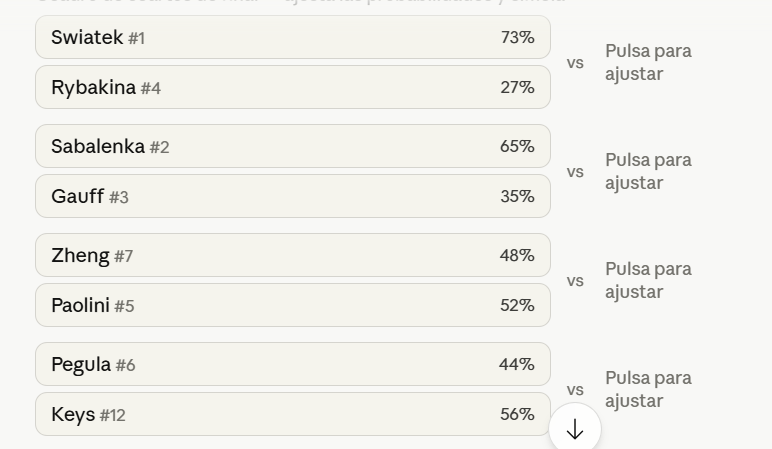

Simulación del cuadro, llamo al predictor en cada partido, cargo la predicción obtenida

Clasificador  →  predict_proba()  →  probabilidad  →  dado cargado  →  ganadora
  (entrena)        (infiere)          [0.73, 0.27]     random()         Swiatek

┌─────────────────────────────────────────┐
│           SIMULACIÓN MONTE CARLO        │  ← repite 10.000 veces
│                                         │
│   Cuartos → Semis → Final               │
│   para cada partido llama a...          │
│                                         │
│   ┌─────────────────────────────────┐   │
│   │         MODELO ML               │   │  ← entrenado con datos históricos
│   │  input: jugadora A vs B         │   │
│   │  output: probabilidad 0..1      │   │
│   └─────────────────────────────────┘   │
│                                         │
└─────────────────────────────────────────┘
         ↓ resultado final
   {"Swiatek": 38%, "Sabalenka": 22%, ...}

1. PREPARAR DATASET
   wta.csv → calcular features → df_modelo (guardar como CSV)

2. ENTRENAR
   df_modelo[2007:2023] → train → Random Forest / XGBoost
   df_modelo[2024:2025] → test  → accuracy + comparar con odds

3. SIMULAR ROLAND GARROS
   cuadro Australian Open 2025 (adaptado)
   + ranking WTA actual
   + forma_reciente calculada con fecha de hoy
   → Monte Carlo 10.000 veces
   → probabilidades por jugadora

4. (OPCIONAL) STREAMLIT
   Input: dos jugadoras + superficie
   Output: probabilidades + simulación torneo

Fase 1 — entrenamiento: aprende de 44.000 partidos históricos. Esto pasa una vez.
Fase 2 — inferencia: dado un cuadro real, preguntas al modelo miles de veces. Esto pasa cuando quieres predecir.

Cuotas de apuestas: (ej: 1.33 vs 3.00)
Es un predictor genial pero claro, no voy a tenerlo antes de los partidos en el simulador de Roland Garros.
Solo existen cuando el partido ya está anunciado y las casas las publican
Conversor de cuota a porcentaje: 1/cuota. 1/1.33 = 75%
Creo que lo quitaré del entrenamiento y de alguna forma puedo usarlo como medida de cuanto de bueno es mi predictor vs casas de apuestas

Valoraré si incluir estadísticas adicionales. Por el momento buscar cómo inferir datos adicionales de los datos que hay.
Estado de forma:
% partidos ganados en los últimos 2-3 meses?
% sets ganados en el último 2-3 meses?

Histórico:
Head to head histórico
Win rate de cada jugadora en esa superficie concreta
Win rate en esa ronda concreta (hay jugadoras que rinden mejor en finales)
Ratio Puntos Totales Ganados/Perdidos 

Tendría que buscar:
% Primer Servicio
% Puntos con 2do Servicio
% Juegos Ganados al Saque: Solidez del servicio. 
% Puntos de Break Points) Convertir oportunidades de quiebre y salvar las propias es crucial para ganar partidos ajustados.
Errores No Forzados vs. Golpes Ganadores:  

Simulador de partido. Solo actual? Entiendo que es mejor. No tiene sentido simular partidos pasados

Simulador de torneo. Cosas a tener en cuenta:
- Sacar ranking

# Metricas

In [ ]:
#Accuracy y AUC-ROC
# es más correcto conceptualmente usar AUC-ROC para optimizar los modelos
#  porque el objetivo del modelo es generar probabilidades para la simulación,
#  no clasificar con un umbral fijo

from sklearn.metrics import roc_auc_score

# AUC de tu modelo
y_proba_modelo = xgb_best.predict_proba(X_test)[:, 1]
auc_modelo = roc_auc_score(y_test, y_proba_modelo)

# AUC de las casas — usas sus probabilidades directamente
prob_casas = df.loc[df_test['match_id'], 'odd_1'].values
mask = ~np.isnan(prob_casas)

auc_casas = roc_auc_score(y_test[mask], prob_casas[mask])

print(f'AUC modelo: {auc_modelo:.4f}')
print(f'AUC casas:  {auc_casas:.4f}')

# Otras features

- Variación del ranking (si viene en tendencia positiva o negativa. coger otro margen de tiempo para que capte algo diferente del winrate2meses)
- Inactividad: Días de descanso desde último partido (limitar a maximo - un año igual)
- Capar más la diferencia de ranking? rank_diff_clipped = min(max(rank_diff, -50), 50)
- Ponderación por años (dar menos peso a los más antiguos)
- ELO! 

El sistema de coeficiente Elo en el tenis es un método estadístico diseñado para medir la habilidad relativa de los jugadores, ajustando su puntuación tras cada partido en función del resultado y la fuerza del oponente. A diferencia del ranking oficial ATP/WTA, que se basa en la acumulación de puntos por rondas alcanzadas en 52 semanas, el Elo es dinámico y evalúa la calidad de cada victoria individual  
La idea es simple: cada jugadora tiene una puntuación numérica que sube cuando gana y baja cuando pierde, pero la cantidad que sube o baja depende de la dificultad del rival:

Se puede mejorar el modelo incluyendo  perfiles de la jugadora? 

Resumen del pipeline completo  

- Calcular medias por jugadora (seleccionando bien qué stats usar)
- Generar dataset jugadora → medias
- Escalar con StandardScaler
- KMeans — prueba con k=3 o k=4, usa el método del codo para decidir
- Merge al dataset principal por nombre de jugadora
- Añadir cluster como feature categórica para p1 y p2

Pendientes:
- Incluir los gráficos en la memoria
- Streamlit. los colores, qué pasa con las simulaciones
- Subir al repositorio una versión de cómo está ahora funcionando en el esquema que se pide
- Presentación: Kmeans escalada irracional. justificar aumento de la inversión en tiempo basándose en la inversión de tiempo anterior
- Reduccion features? Intentar hacer alguna prueba para mejorar el modelo (cambiar pesos? decaimiento??)